Date: 14/03/2026

Sanskriti Saurabh

Superset ID: 6784944


Project Scenario: Smart Waste Classification System
A city municipality wants to build an AI-powered waste segregation system that can automatically classify images of waste into:

Recyclable Waste

Organic Waste

Non-Recyclable Waste

You are required to build a deep learning image classifier that can perform this task.

Task 1 – Dataset Collection (5 Marks)
Download or collect a dataset of waste images from sources

https://www.kaggle.com/datasets/asdasdasasdas/garbage-classification?utm_source=chatgpt.com


Organize the dataset into the following folder structure:

dataset/

   train/

       recyclable/

       organic/

       non_recyclable/


   validation/

       recyclable/

       organic/

       non_recyclable/


Deliverable:
• Show the dataset structure and total number of images in each class.

In [16]:
import os
import zipfile
import shutil
from sklearn.model_selection import train_test_split

In [18]:
#extracting the files
zip_path = "/content/archive.zip"
extract_path = "/content/archive"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [25]:
base_dir = "/content/archive"

classes = ["recyclable", "organic", "non_recyclable"]

for split in ["train", "validation"]:
    for cls in classes:
        os.makedirs(os.path.join(base_dir, split, cls), exist_ok=True)

print("Folder structure created")

Folder structure created


In [26]:
import os
from sklearn.model_selection import train_test_split

base_dir = "/content/archive"

mapping = {
    "cardboard": "recyclable",
    "glass": "recyclable",
    "metal": "recyclable",
    "paper": "recyclable",
    "plastic": "recyclable",
    "trash": "non_recyclable"
}

source_dir = "/content/archive/garbage classification/Garbage classification"

In [27]:
for original_class, new_class in mapping.items():

    class_path = os.path.join(source_dir, original_class)
    images = os.listdir(class_path)

    train_imgs, val_imgs = train_test_split(images, test_size=0.2, random_state=42)

    # copy train images
    for img in train_imgs:
        src = os.path.join(class_path, img)
        dst = os.path.join(base_dir, "train", new_class)
        shutil.copy(src, dst)

    # copy validation images
    for img in val_imgs:
        src = os.path.join(class_path, img)
        dst = os.path.join(base_dir, "validation", new_class)
        shutil.copy(src, dst)

print("Dataset organized successfully")

Dataset organized successfully


In [28]:
for split in ["train", "validation"]:
    print("\n", split.upper())

    for cls in classes:
        folder = os.path.join(base_dir, split, cls)
        count = len(os.listdir(folder))
        print(f"{cls}: {count} images")


 TRAIN
recyclable: 1910 images
organic: 0 images
non_recyclable: 109 images

 VALIDATION
recyclable: 480 images
organic: 0 images
non_recyclable: 28 images


Task 2 – Data Preprocessing (5 Marks)
Perform the following preprocessing steps:

Resize images to a fixed size (e.g., 224×224)

Normalize pixel values

Apply data augmentation (at least 3 techniques)

Examples:

Rotation

Horizontal flip

Zoom

Brightness adjustment

Deliverable:
• Show the preprocessing pipeline code.

In [29]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [31]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_dir = "/content/archive/train"
val_dir = "/content/archive/validation"

In [32]:
train_datagen = ImageDataGenerator(

    rescale=1./255,            # Normalize pixel values

    rotation_range=30,         # Random rotation
    horizontal_flip=True,      # Flip images
    zoom_range=0.2,            # Random zoom
    brightness_range=[0.8,1.2] # Brightness adjustment

)

In [33]:
validation_datagen = ImageDataGenerator(
    rescale=1./255
)

In [34]:
train_generator = train_datagen.flow_from_directory(

    train_dir,

    target_size=IMG_SIZE,      # Resize images to 224x224
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

validation_generator = validation_datagen.flow_from_directory(

    val_dir,

    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

Found 2019 images belonging to 3 classes.
Found 508 images belonging to 3 classes.


In [35]:
print("Classes:", train_generator.class_indices)

print("Training batches:", len(train_generator))

print("Validation batches:", len(validation_generator))

Classes: {'non_recyclable': 0, 'organic': 1, 'recyclable': 2}
Training batches: 64
Validation batches: 16


Task 3 – CNN Model Development (8 Marks)
Build an image classification model using CNN.

Your model should include:

Convolution layers

Pooling layers

Dense layers

Softmax output layer

Train the model and display:

Training accuracy

Validation accuracy

Training loss curve

Deliverable:

• Model architecture
• Training output
• Accuracy graph

In [36]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
import matplotlib.pyplot as plt

In [37]:
model = Sequential([

    # Convolution Layer 1
    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(pool_size=(2,2)),

    # Convolution Layer 2
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Convolution Layer 3
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    # Flatten layer
    Flatten(),

    # Dense Layers
    Dense(128, activation='relu'),
    Dropout(0.5),

    # Output Layer (3 classes)
    Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [38]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [39]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,347 (42.61 MB)

 Trainable params: 11,169,347 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [42]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=2
)

Epoch 1/2
64/64 ━━━━━━━━━━━━━━━━━━━━ 277s 4s/step - accuracy: 0.9455 - loss: 0.2104 - val_accuracy: 0.9449 - val_loss: 0.1791
Epoch 2/2
64/64 ━━━━━━━━━━━━━━━━━━━━ 264s 4s/step - accuracy: 0.9460 - loss: 0.1934 - val_accuracy: 0.9449 - val_loss: 0.1915


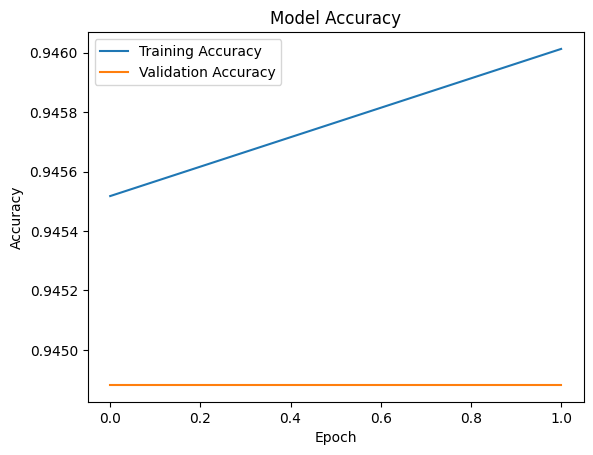

In [43]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

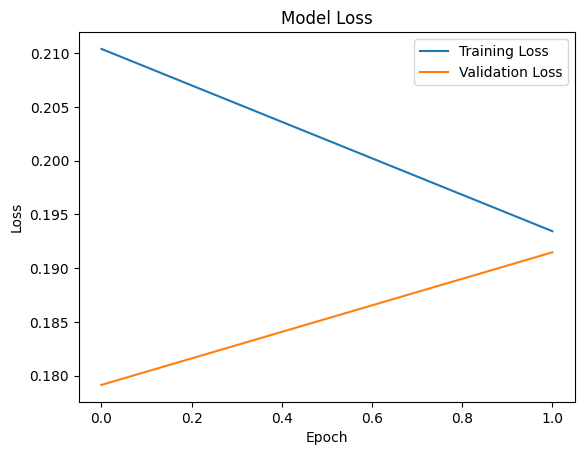

In [44]:
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

Task 4 – Model Evaluation (6 Marks)
Evaluate the trained model using:

Confusion Matrix

Accuracy score

Sample predictions on test images

Deliverable:

• Confusion matrix visualization
• 5 test image predictions with predicted labels

In [46]:
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score
from tensorflow.keras.preprocessing import image
import random

In [47]:

predictions = model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = validation_generator.classes

class_labels = list(validation_generator.class_indices.keys())

16/16 ━━━━━━━━━━━━━━━━━━━━ 31s 2s/step


In [48]:
accuracy = accuracy_score(true_classes, predicted_classes)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9448818897637795


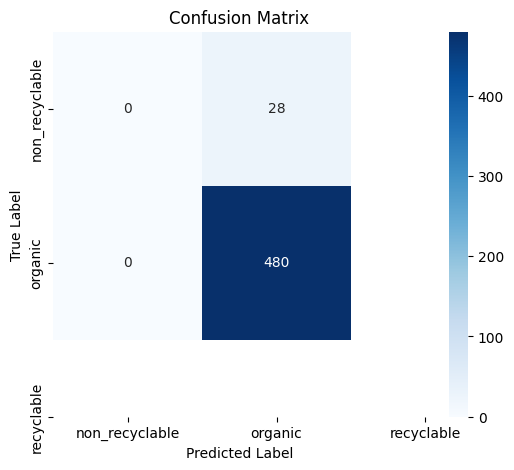

In [50]:
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.show()

In [51]:
test_dir = "/content/archive/validation"

all_images = []

for cls in class_labels:
    folder = os.path.join(test_dir, cls)
    for img in os.listdir(folder):
        all_images.append(os.path.join(folder, img))

# choose 5 random images
sample_images = random.sample(all_images, 5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 171ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step


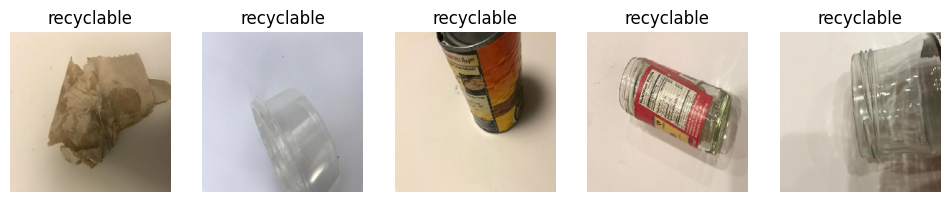

In [52]:
plt.figure(figsize=(12,6))

for i, img_path in enumerate(sample_images):

    img = image.load_img(img_path, target_size=(224,224))
    img_array = image.img_to_array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediction = model.predict(img_array)
    predicted_label = class_labels[np.argmax(prediction)]

    plt.subplot(1,5,i+1)
    plt.imshow(img)
    plt.title(predicted_label)
    plt.axis("off")

plt.show()

Task 5 – Transfer Learning Implementation (6 Marks)
Improve your system by implementing Transfer Learning using a pretrained model such as:

ResNet50

MobileNetV2

VGG16

Steps:

Load a pretrained model

Freeze base layers

Add custom classification layers

Train the model

Compare results with your original CNN model.

Deliverable:

• Accuracy comparison between Custom CNN vs Transfer Learning model

In [53]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout

In [54]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [55]:
#freeze base layers
for layer in base_model.layers:
    layer.trainable = False

In [56]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation='relu')(x)

x = Dropout(0.5)(x)

output = Dense(3, activation='softmax')(x)

transfer_model = Model(inputs=base_model.input, outputs=output)

In [57]:
transfer_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [58]:
transfer_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [60]:
transfer_history = transfer_model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=5
)

Epoch 1/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.9440 - loss: 0.2259 - val_accuracy: 0.9449 - val_loss: 0.1887
Epoch 2/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 160s 3s/step - accuracy: 0.9495 - loss: 0.1452 - val_accuracy: 0.9626 - val_loss: 0.1009
Epoch 3/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 152s 2s/step - accuracy: 0.9569 - loss: 0.1278 - val_accuracy: 0.9528 - val_loss: 0.1173
Epoch 4/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 139s 2s/step - accuracy: 0.9599 - loss: 0.1116 - val_accuracy: 0.9626 - val_loss: 0.0880
Epoch 5/5
64/64 ━━━━━━━━━━━━━━━━━━━━ 137s 2s/step - accuracy: 0.9589 - loss: 0.0998 - val_accuracy: 0.9626 - val_loss: 0.0973


In [61]:
cnn_accuracy = history.history['val_accuracy'][-1]
transfer_accuracy = transfer_history.history['val_accuracy'][-1]

print("Custom CNN Validation Accuracy:", cnn_accuracy)
print("Transfer Learning Validation Accuracy:", transfer_accuracy)

Custom CNN Validation Accuracy: 0.9448819160461426
Transfer Learning Validation Accuracy: 0.962598443031311


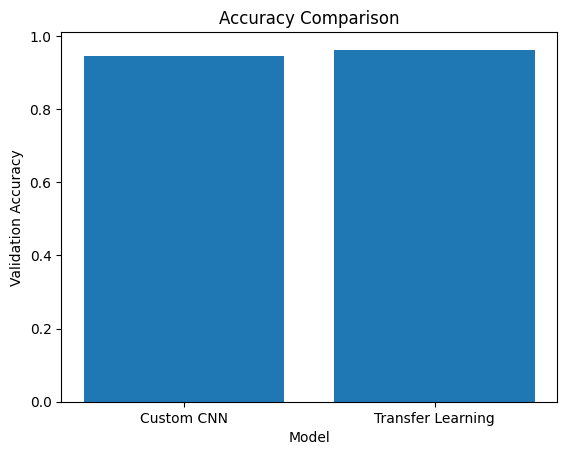

In [62]:
import matplotlib.pyplot as plt

models = ['Custom CNN', 'Transfer Learning']
accuracies = [cnn_accuracy, transfer_accuracy]

plt.bar(models, accuracies)

plt.title("Accuracy Comparison")
plt.ylabel("Validation Accuracy")
plt.xlabel("Model")

plt.show()

# Project Scenerio 2

AI Research Assistant for Students
A university wants to build an AI-powered Research Assistant that can help students quickly understand long academic articles and generate structured insights.

The system should be able to:

Summarize long text


Extract key insights


Answer questions about the content


Generate concise explanations


You are required to design and implement a prototype using a Large Language Model (LLM).

Task 1 – LLM Interaction Setup (5 Marks)
Use any LLM API such as:

Gemini


OpenAI


HuggingFace Transformers


Steps:

Write Python code to send a text prompt to an LLM.


Provide a sample long article or research paragraph.


Generate a summary using the LLM.


Deliverable:

Python code


Input text sample


Generated output

In [ ]:
!pip install transformers torch sentencepiece

In [67]:
from transformers import pipeline
model = pipeline(
    "text-generation",
    model="google/flan-t5-base"
)

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

The model 'T5ForConditionalGeneration' is not supported for text-generation. Supported models are ['PeftModelForCausalLM', 'AfmoeForCausalLM', 'ApertusForCausalLM', 'ArceeForCausalLM', 'AriaTextForCausalLM', 'BambaForCausalLM', 'BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BitNetForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'BltForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'Cohere2ForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'CwmForCausalLM', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'DeepseekV2ForCausalLM', 'DeepseekV3ForCausalLM', 'DiffLlamaForCausalLM', 'DogeForCausalLM', 'Dots1ForCausalLM', 'ElectraForCausalLM', 'Emu3ForCausalLM', 'ErnieForCausalLM', 'Ernie4_5ForCausalLM', 'Ernie4_5_MoeForCausalLM', 'Exaone4ForCausalLM', 'FalconForCausalLM', 'FalconH1ForCausalLM', 'FalconMambaForCausa

In [68]:
article = """
Artificial Intelligence (AI) is rapidly transforming modern education.
AI-powered systems can analyze student performance and personalize learning
experiences for each individual. Machine learning algorithms enable automated
grading, intelligent tutoring systems, and adaptive learning platforms.
These technologies help educators identify learning gaps and provide targeted
support to students. However, ethical concerns such as data privacy,
algorithmic bias, and responsible AI usage must be addressed carefully.
"""

In [69]:
prompt = "Summarize the following research paragraph:\n" + article

result = model(
    prompt,
    max_length=120,
    do_sample=True
)

print("Generated Summary:\n")
print(result[0]["generated_text"])

Passing `generation_config` together with generation-related arguments=({'max_length', 'do_sample'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
Both `max_new_tokens` (=256) and `max_length`(=120) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Generated Summary:

Summarize the following research paragraph:

Artificial Intelligence (AI) is rapidly transforming modern education.
AI-powered systems can analyze student performance and personalize learning
experiences for each individual. Machine learning algorithms enable automated
grading, intelligent tutoring systems, and adaptive learning platforms.
These technologies help educators identify learning gaps and provide targeted
support to students. However, ethical concerns such as data privacy,
algorithmic bias, and responsible AI usage must be addressed carefully.
hould happen through using robot software' on human workers instead: Discuss possible privacy laws under certain law-area districts' and university rules where approtuations require respect? Learn our most concrete recommendation while researching advancing automation among professional, civic anthropographical literature, civic debate papers writing collections via email through social media/ancy to educate young c

Task 2 – Prompt Engineering Experiments
1️⃣ Zero-Shot Prompt
Ask the model to summarize the article without providing examples.

Example task:

Summarize the following article in 5 bullet points


Ans: Read the following research article and summarize the important information.
Provide the summary as exactly five clear bullet points that capture the main findings and ideas of the article.

Article:
'Insert Research Article Here'

2️⃣ Few-Shot Prompt
Provide 2 example summaries before asking the model to summarize a new article

Ans:  You are an AI research assistant that summarizes academic articles.

Example 1
Article:
Online education platforms allow students to access learning materials remotely and learn at their own pace.

Summary:
• Online platforms enable remote learning.
• Students can learn at flexible schedules.
• Digital education increases accessibility.

Example 2
Article:
Blockchain technology creates secure digital records that cannot easily be modified, making it useful for financial transactions.

Summary:
• Blockchain stores secure and immutable data.
• It increases transparency in financial systems.
• It reduces the risk of fraud.

Now summarize the following article using the same bullet-point style.

Article:
'Insert Research Article Here'

3️⃣ Chain-of-Thought Prompt
Ask the model to reason step-by-step before generating the summary.

Example structure:

Analyze the article step by step:

1. Identify the main topic

2. Extract key ideas

3. Generate a concise summary

Deliverable:

All three prompts


Model outputs


Comparison of responses

Ans:  You are an AI research assistant that helps students understand academic articles.

Follow this reasoning process before generating the final answer:

Step 1: Identify the main research topic of the article.
Step 2: Extract the most important concepts or findings.
Step 3: Combine these ideas into a short and clear summary.

After completing the steps, present a final summary in bullet points.

Article:
[Insert Research Article Here]

# Comparison of the Three prompting strategies
1. Prompting Method->
Zero-Shot Prompt

Characteristics	->	Only instruction is provided, no examples

Output Quality-> Good but sometimes less structured

2. Prompting Method->
Few-Shot Prompt

Characteristics	->	Includes examples before the task

Output Quality-> More consistent and better formatted output

3. Prompting Method->
Chain-of-Thought Prompt

Characteristics	->	Model reasons step-by-step

Output Quality-> Most detailed and logically structured response

Task 3 – Prompt Optimization (7 Marks)
Improve the prompt so that the AI generates better executive summaries.

Your optimized prompt must produce:

3 key insights


1 actionable takeaway


Professional tone


Test the optimized prompt on two different articles.

Deliverable:

Final optimized prompt


Two example outputs


In [82]:
optimized_prompt = """
You are an AI research assistant.

Read the article carefully and produce an executive summary with the following structure:

Key Insights:
1.
2.
3.

Actionable Takeaway:
Provide one practical recommendation based on the article.

Ensure the response is clear, concise, and written in a professional academic tone.

Article:
"""

In [83]:
article1 = """
Artificial Intelligence is transforming modern education through personalized
learning systems. Machine learning algorithms analyze student performance data
to adapt educational materials based on individual learning patterns.
AI-powered tutoring systems can provide real-time assistance to students,
while automated grading systems reduce the workload of educators.
However, the adoption of AI in education also raises ethical concerns
related to student data privacy and algorithmic bias.
"""

In [84]:
prompt1 = optimized_prompt + article1

result1 = model(
    prompt1,
    max_length=200,
    do_sample=True
)

print("Output for Article 1:\n")
print(result1[0]["generated_text"])

Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Output for Article 1:


You are an AI research assistant.

Read the article carefully and produce an executive summary with the following structure:

Key Insights:
1.
2.
3.

Actionable Takeaway:
Provide one practical recommendation based on the article.

Ensure the response is clear, concise, and written in a professional academic tone.

Article:

Artificial Intelligence is transforming modern education through personalized
learning systems. Machine learning algorithms analyze student performance data
to adapt educational materials based on individual learning patterns.
AI-powered tutoring systems can provide real-time assistance to students,
while automated grading systems reduce the workload of educators.
However, the adoption of AI in education also raises ethical concerns
related to student data privacy and algorithmic bias.
vailable online educational institutions cannot allow users time spent alone (it allows people at university without the college of choice...) with better supp

In [86]:
article2 = """
Renewable energy technologies such as solar, wind, and hydropower are
becoming increasingly important for addressing climate change.
These energy sources produce little to no greenhouse gas emissions
compared to fossil fuels. Governments worldwide are investing in
renewable infrastructure and research to accelerate the transition
toward sustainable energy systems. However, challenges such as high
initial costs and energy storage limitations still need to be addressed.
"""

In [87]:
prompt2 = optimized_prompt + article2

result2 = model(
    prompt2,
    max_length=200,
    do_sample=True
)

print("\nOutput for Article 2:\n")
print(result2[0]["generated_text"])

Both `max_new_tokens` (=256) and `max_length`(=200) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



Output for Article 2:


You are an AI research assistant.

Read the article carefully and produce an executive summary with the following structure:

Key Insights:
1.
2.
3.

Actionable Takeaway:
Provide one practical recommendation based on the article.

Ensure the response is clear, concise, and written in a professional academic tone.

Article:

Renewable energy technologies such as solar, wind, and hydropower are
becoming increasingly important for addressing climate change.
These energy sources produce little to no greenhouse gas emissions
compared to fossil fuels. Governments worldwide are investing in
renewable infrastructure and research to accelerate the transition
toward sustainable energy systems. However, challenges such as high
initial costs and energy storage limitations still need to be addressed.



Task 4 – Tokenization Experiment (5 Marks)
Use a tokenizer from HuggingFace or any LLM library.

Steps:

Tokenize a paragraph of text.


Count the total number of tokens.


Display the tokenized output.


Example tools:

tiktoken


transformers tokenizer


Deliverable:

Python code


Token count


Example tokenized output

In [88]:
from transformers import AutoTokenizer

# Load tokenizer (GPT-2 tokenizer)
tokenizer = AutoTokenizer.from_pretrained("gpt2")

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [89]:
text = """
Artificial Intelligence is transforming education by enabling personalized
learning experiences. Machine learning algorithms analyze student performance
data and adapt educational content to individual needs.
"""

tokens = tokenizer.tokenize(text)

In [90]:
token_ids = tokenizer.convert_tokens_to_ids(tokens)

In [91]:
token_count = len(tokens)

In [92]:
print("Original Text:\n", text)

print("\nTokenized Output:\n", tokens)

print("\nToken IDs:\n", token_ids)

print("\nTotal Number of Tokens:", token_count)

Original Text:
 
Artificial Intelligence is transforming education by enabling personalized
learning experiences. Machine learning algorithms analyze student performance
data and adapt educational content to individual needs.


Tokenized Output:
 ['Ċ', 'Art', 'ificial', 'ĠIntelligence', 'Ġis', 'Ġtransforming', 'Ġeducation', 'Ġby', 'Ġenabling', 'Ġpersonalized', 'Ċ', 'learning', 'Ġexperiences', '.', 'ĠMachine', 'Ġlearning', 'Ġalgorithms', 'Ġanalyze', 'Ġstudent', 'Ġperformance', 'Ċ', 'data', 'Ġand', 'Ġadapt', 'Ġeducational', 'Ġcontent', 'Ġto', 'Ġindividual', 'Ġneeds', '.', 'Ċ']

Token IDs:
 [198, 8001, 9542, 9345, 318, 25449, 3707, 416, 15882, 28949, 198, 40684, 6461, 13, 10850, 4673, 16113, 16602, 3710, 2854, 198, 7890, 290, 6068, 9856, 2695, 284, 1981, 2476, 13, 198]

Total Number of Tokens: 31


Task 5 – Build a Mini AI Tool (5 Marks)
Create a simple AI assistant that takes a long article and produces:

A short summary


Key insights


One actionable recommendation


The program should:

Accept text input


Send prompt to LLM


Display structured output


Deliverable:

Python script or notebook


Example result


In [93]:
def ai_research_assistant(article):

    prompt = f"""
You are an AI research assistant.

Read the following article and generate:

Summary:
Write a short summary of the article.

Key Insights:
1.
2.
3.

Actionable Recommendation:
Provide one practical recommendation based on the article.

Article:
{article}
"""

    result = generator(
        prompt,
        max_length=250,
        num_return_sequences=1,
        temperature=0.7
    )

    output = result[0]["generated_text"]

    print("\n===== AI Research Assistant Output =====\n")
    print(output)


In [ ]:
article = """
Artificial Intelligence is transforming education by enabling personalized
learning experiences. Machine learning algorithms analyze student performance
data and adapt educational content to individual learning styles.
AI tutoring systems can provide real-time assistance to students,
while automated grading tools reduce the workload of teachers.
However, concerns regarding data privacy and algorithmic bias must be addressed
to ensure responsible adoption of AI in educational environments.
"""

ai_research_assistant(article)